In [3]:
# Model Evaluation Regression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

# 1. Load Dataset
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
print("Dataset loaded successfully")

Dataset loaded successfully


In [4]:
# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.2, random_state=42
)

In [6]:
# 3. Models
models = {
 "Linear Regression": LinearRegression(),
 "Random Forest": RandomForestRegressor(n_estimators=200,random_state=42),
 "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}


In [7]:
# 4. Evaluation Function
def adjusted_r2(r2, n, p):
 return 1 - (1 - r2) * (n - 1) / (n - p - 1)
results = []

In [8]:
# 5. Train + Evaluate
for name, model in models.items():
 model.fit(X_train, y_train)
 y_pred = model.predict(X_test)
 mae = mean_absolute_error(y_test, y_pred)
 mse = mean_squared_error(y_test, y_pred)
 rmse = np.sqrt(mse)
 r2 = r2_score(y_test, y_pred)
 adj_r2 = adjusted_r2(r2, X_test.shape[0], X_test.shape[1])
 results.append([name, mae, mse, rmse, r2, adj_r2])

In [9]:
# 6. Results Table
results_df = pd.DataFrame(results, columns=[
 "Model", "MAE", "MSE", "RMSE", "R2", "Adjusted R2"
])
results_df.head()

,Model,MAE,MSE,RMSE,R2,Adjusted R2
0,Linear Regression,0.533200,0.555892,0.745581,0.575788,0.574964
1,Random Forest,0.326782,0.253956,0.503940,0.806201,0.805825
2,Gradient Boosting,0.371643,0.293997,0.542215,0.775645,0.775209


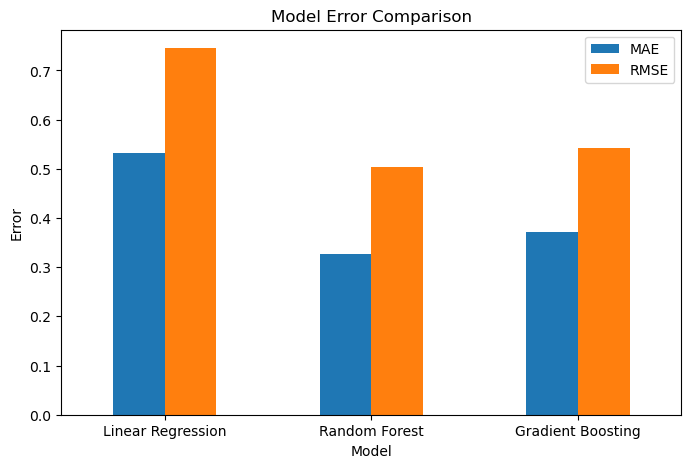

In [10]:
# 7. Visualization
results_df.set_index("Model")[["MAE", "RMSE"]].plot(kind="bar",
figsize=(8,5))
plt.title("Model Error Comparison")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.show()